# RQ3: Linguistic Patterns Behind Neutral (3-star) Misclassification

This notebook answers:

**RQ3:** What linguistic patterns (contrastive conjunctions, negations, conditionals) contribute to DistilBERT misclassifying neutral (3-star) reviews?

## Outputs
- `rq3_outputs/neutral_subset_with_preds.csv`
- `rq3_outputs/rq3_pattern_summary.csv`
- `rq3_outputs/rq3_top_pattern_combos.csv`
- `rq3_outputs/rq3_sample_misclassified_neutral.csv`
- `rq3_outputs/rq3_pattern_rates.png`

## Notes
- Uses your saved DistilBERT model if available (`distilbert_final_v2` preferred).
- Falls back to local checkpoints if needed.
- Works with `cleaned_amazon_random_reviews.csv` by default.

In [16]:
# If needed, uncomment and run once in your selected kernel
# %pip install -q pandas numpy matplotlib seaborn transformers torch

In [17]:
import re
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

BASE_DIR = Path.cwd()
OUTPUT_DIR = BASE_DIR / "rq3_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Use a smaller sample for quick iteration; set to None for full run.
MAX_ROWS = 20000
BATCH_SIZE = 32

print("Base dir:", BASE_DIR)
print("Output dir:", OUTPUT_DIR)

Base dir: /Users/jainesh/Downloads/Deep Learning/6165 group
Output dir: /Users/jainesh/Downloads/Deep Learning/6165 group/rq3_outputs


In [18]:
# --------- Locate dataset ---------
DATA_CANDIDATES = [
    BASE_DIR / "cleaned_amazon_random_reviews.csv",
    BASE_DIR / "sports_random_50k_final.csv",
    BASE_DIR / "cleaned_amazon_reviews.csv",
]

data_path = next((p for p in DATA_CANDIDATES if p.exists()), None)
if data_path is None:
    raise FileNotFoundError("No candidate RQ3 dataset found. Update DATA_CANDIDATES.")

print("Using dataset:", data_path)
df = pd.read_csv(data_path)
if MAX_ROWS is not None:
    df = df.head(MAX_ROWS).copy()

print("Shape:", df.shape)
print("Columns:", list(df.columns))

Using dataset: /Users/jainesh/Downloads/Deep Learning/6165 group/cleaned_amazon_random_reviews.csv
Shape: (20000, 16)
Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'product_name', 'sentiment', 'word_count', 'text_length', 'helpful_log', 'clean_text_final']


In [19]:
# --------- Resolve text + neutral label ---------
TEXT_COL_CANDIDATES = ["clean_text_final", "clean_text", "text", "review_text", "content"]
text_col = next((c for c in TEXT_COL_CANDIDATES if c in df.columns), None)
if text_col is None:
    raise ValueError(f"No text column found in {TEXT_COL_CANDIDATES}")

if "rating" in df.columns:
    rating = pd.to_numeric(df["rating"], errors="coerce")
    true_label = pd.Series(np.where(rating <= 2, 0, np.where(rating == 3, 1, 2)), index=df.index)
elif "sentiment" in df.columns:
    true_label = pd.to_numeric(df["sentiment"], errors="coerce")
else:
    raise ValueError("Need either 'rating' or 'sentiment' column.")

work_df = df.copy()
work_df["text_for_model"] = work_df[text_col].fillna("").astype(str)
work_df["true_label"] = true_label.astype("Int64")

# Keep valid text + label rows only
work_df = work_df[(work_df["text_for_model"].str.strip() != "") & (work_df["true_label"].notna())].copy()
work_df["true_label"] = work_df["true_label"].astype(int)

neutral_df = work_df[work_df["true_label"] == 1].copy()
print("Text column:", text_col)
print("Total usable rows:", len(work_df))
print("Neutral rows (3-star equivalent):", len(neutral_df))

Text column: clean_text_final
Total usable rows: 19996
Neutral rows (3-star equivalent): 1359


In [20]:
# --------- Locate/load DistilBERT model ---------
MODEL_CANDIDATES = [
    BASE_DIR / "distilbert_final_v2",
    BASE_DIR / "distilbert_final_v1",
    BASE_DIR / "distilbert_output" / "checkpoint-9938",
    BASE_DIR / "distilbert_output" / "checkpoint-7454",
]

ZIP_CANDIDATES = [
    BASE_DIR / "distilbert_final_v2.zip",
    BASE_DIR / "distilbert_final_v1.zip",
]

model_dir = next((p for p in MODEL_CANDIDATES if p.exists()), None)

if model_dir is None:
    zip_path = next((p for p in ZIP_CANDIDATES if p.exists()), None)
    if zip_path is None:
        raise FileNotFoundError("No model folder/zip found. Add your distilbert_final_v2 path.")
    extract_to = BASE_DIR / zip_path.stem
    if not extract_to.exists():
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(extract_to)
    model_dir = extract_to

print("Using model dir:", model_dir)

# Try direct load; if zip extracted to nested folder, look for first directory with config.json
if not (model_dir / "config.json").exists():
    nested = [p.parent for p in model_dir.rglob("config.json")]
    if nested:
        model_dir = nested[0]
        print("Adjusted model dir:", model_dir)

device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained(model_dir)
model = AutoModelForSequenceClassification.from_pretrained(model_dir).to(device)
model.eval()

print("Device:", device)
print("Model labels:", model.config.num_labels)

Using model dir: /Users/jainesh/Downloads/Deep Learning/6165 group/distilbert_output/checkpoint-9938


Loading weights: 100%|██████████| 104/104 [00:00<00:00, 855.57it/s]


Device: cpu
Model labels: 3


In [21]:
# --------- Predict on neutral subset ---------
def predict_labels(texts, batch_size=32):
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(
            batch,
            truncation=True,
            padding=True,
            max_length=256,
            return_tensors="pt"
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            pred = torch.argmax(logits, dim=1).detach().cpu().numpy()
        preds.extend(pred.tolist())
    return np.array(preds)

neutral_df = neutral_df.reset_index(drop=True)
neutral_df["pred_label"] = predict_labels(neutral_df["text_for_model"].tolist(), batch_size=BATCH_SIZE)
neutral_df["is_misclassified"] = neutral_df["pred_label"] != neutral_df["true_label"]

mis_rate = neutral_df["is_misclassified"].mean()
print(f"Neutral misclassification rate: {mis_rate:.4f}")
print(neutral_df["pred_label"].value_counts(dropna=False).sort_index())

neutral_df.to_csv(OUTPUT_DIR / "neutral_subset_with_preds.csv", index=False)

Neutral misclassification rate: 0.0353
pred_label
0      48
1    1311
Name: count, dtype: int64


In [22]:
# --------- Linguistic pattern extraction ---------
contrastive_terms = ["but", "however", "although", "though", "yet", "while"]
negation_terms = ["not", "never", "no", "none", "nothing", "hardly", "barely", "n't"]
conditional_terms = ["if", "would", "could", "should", "unless", "provided", "might", "may"]

contrastive_re = re.compile(r"\b(?:" + "|".join(map(re.escape, contrastive_terms)) + r")\b", re.IGNORECASE)
negation_re = re.compile(r"\b(?:" + "|".join(map(re.escape, negation_terms)) + r")\b", re.IGNORECASE)
conditional_re = re.compile(r"\b(?:" + "|".join(map(re.escape, conditional_terms)) + r")\b", re.IGNORECASE)

def count_pattern(regex, text):
    return len(regex.findall(text))

for col, regex in [
    ("contrastive_count", contrastive_re),
    ("negation_count", negation_re),
    ("conditional_count", conditional_re),
]:
    neutral_df[col] = neutral_df["text_for_model"].apply(lambda x: count_pattern(regex, x))
    neutral_df[col.replace("_count", "_present")] = neutral_df[col] > 0

neutral_df["pattern_combo"] = (
    neutral_df["contrastive_present"].astype(int).astype(str)
    + neutral_df["negation_present"].astype(int).astype(str)
    + neutral_df["conditional_present"].astype(int).astype(str)
)

neutral_df[["contrastive_count", "negation_count", "conditional_count"]].describe()

,contrastive_count,negation_count,conditional_count
count,1359.000000,1359.000000,1359.000000
mean,0.082414,0.030169,0.359823
std,0.300674,0.187541,0.742685
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,1.000000
max,3.000000,2.000000,5.000000


In [23]:
# --------- Compare rates: correct vs misclassified neutrals ---------
group_cols = ["contrastive_present", "negation_present", "conditional_present"]
summary_rows = []

for c in group_cols:
    tmp = neutral_df.groupby("is_misclassified")[c].mean().rename("rate").reset_index()
    for _, r in tmp.iterrows():
        summary_rows.append({
            "pattern": c,
            "is_misclassified": bool(r["is_misclassified"]),
            "rate": float(r["rate"]),
        })

summary_df = pd.DataFrame(summary_rows)
pivot_df = summary_df.pivot(index="pattern", columns="is_misclassified", values="rate").reset_index()
pivot_df.columns = ["pattern", "correct_rate", "misclassified_rate"]
pivot_df["difference_mis_minus_correct"] = pivot_df["misclassified_rate"] - pivot_df["correct_rate"]
pivot_df = pivot_df.sort_values("difference_mis_minus_correct", ascending=False)

combo_df = (
    neutral_df.groupby(["pattern_combo", "is_misclassified"]).size().rename("count").reset_index()
)
combo_pivot = combo_df.pivot(index="pattern_combo", columns="is_misclassified", values="count").fillna(0)
combo_pivot.columns = ["correct_count", "misclassified_count"]
combo_pivot["misclassified_share"] = combo_pivot["misclassified_count"] / (combo_pivot["correct_count"] + combo_pivot["misclassified_count"])
combo_pivot = combo_pivot.sort_values("misclassified_share", ascending=False)

pivot_df.to_csv(OUTPUT_DIR / "rq3_pattern_summary.csv", index=False)
combo_pivot.reset_index().to_csv(OUTPUT_DIR / "rq3_top_pattern_combos.csv", index=False)

pivot_df

,pattern,correct_rate,misclassified_rate,difference_mis_minus_correct
2,negation_present,0.028223,0.0,-0.028223
1,contrastive_present,0.078566,0.0,-0.078566
0,conditional_present,0.263158,0.0,-0.263158


In [24]:
# --------- Hypothesis test (chi-square) ---------
# H0: Pattern presence is independent of misclassification status.

try:
    from scipy.stats import chi2_contingency
except Exception:
    chi2_contingency = None

test_rows = []
for p in ["contrastive_present", "negation_present", "conditional_present"]:
    table = pd.crosstab(neutral_df[p], neutral_df["is_misclassified"])

    # Ensure a 2x2 table structure for robustness
    for row_val in [False, True]:
        if row_val not in table.index:
            table.loc[row_val] = [0] * table.shape[1]
    for col_val in [False, True]:
        if col_val not in table.columns:
            table[col_val] = 0
    table = table.sort_index().reindex(columns=[False, True])

    if chi2_contingency is not None and table.values.sum() > 0:
        chi2, p_value, dof, _ = chi2_contingency(table.values)
    else:
        chi2, p_value, dof = np.nan, np.nan, np.nan

    test_rows.append({
        "pattern": p,
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "table_absent_correct": int(table.loc[False, False]),
        "table_absent_mis": int(table.loc[False, True]),
        "table_present_correct": int(table.loc[True, False]),
        "table_present_mis": int(table.loc[True, True]),
    })

chi_square_df = pd.DataFrame(test_rows).sort_values("p_value", na_position="last")
chi_square_df.to_csv(OUTPUT_DIR / "rq3_chi_square_results.csv", index=False)
chi_square_df

,pattern,chi2,p_value,dof,table_absent_correct,table_absent_mis,table_present_correct,table_present_mis
2,conditional_present,15.568502,0.000080,1,966,48,345,0
0,contrastive_present,3.035882,0.081442,1,1208,48,103,0
1,negation_present,0.530835,0.466256,1,1274,48,37,0


In [25]:
# --------- Short printed conclusion: biggest effect ---------
biggest = pivot_df.sort_values("difference_mis_minus_correct", ascending=False).iloc[0]
pattern_name = str(biggest["pattern"]).replace("_present", "")
msg = (
    f"Biggest effect pattern: {pattern_name}. "
    f"Misclassified rate={biggest['misclassified_rate']:.1%}, "
    f"Correct rate={biggest['correct_rate']:.1%}, "
    f"Delta={biggest['difference_mis_minus_correct']:+.1%}."
)
print(msg)

with open(OUTPUT_DIR / "rq3_biggest_effect.txt", "w", encoding="utf-8") as f:
    f.write(msg + "\n")

Biggest effect pattern: negation. Misclassified rate=0.0%, Correct rate=2.8%, Delta=-2.8%.


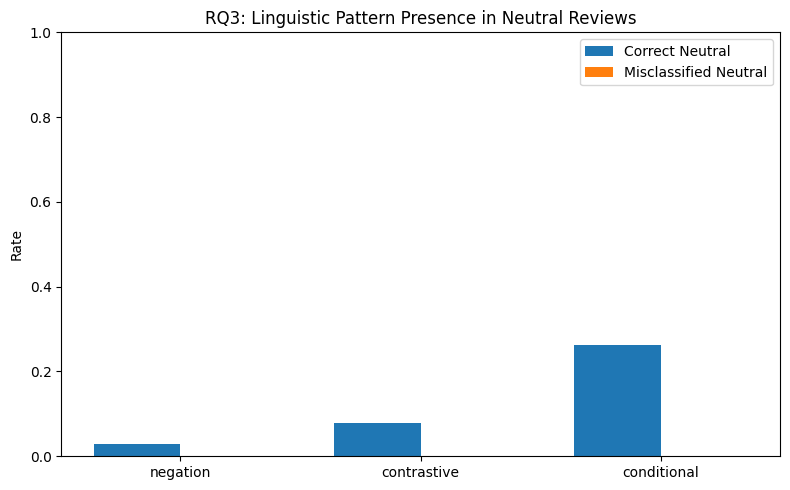

In [26]:
# --------- Plot pattern rates ---------
plot_df = pivot_df.copy()
plot_df["pattern"] = plot_df["pattern"].str.replace("_present", "", regex=False)

x = np.arange(len(plot_df))
width = 0.36

plt.figure(figsize=(8, 5))
plt.bar(x - width / 2, plot_df["correct_rate"], width=width, label="Correct Neutral")
plt.bar(x + width / 2, plot_df["misclassified_rate"], width=width, label="Misclassified Neutral")
plt.xticks(x, plot_df["pattern"])
plt.ylim(0, 1)
plt.ylabel("Rate")
plt.title("RQ3: Linguistic Pattern Presence in Neutral Reviews")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "rq3_pattern_rates.png", dpi=150)
plt.show()

In [27]:
# --------- Qualitative examples for report ---------
example_cols = [c for c in ["rating", "true_label", "pred_label", "is_misclassified", text_col, "contrastive_count", "negation_count", "conditional_count", "pattern_combo"] if c in neutral_df.columns]

mis_examples = neutral_df[neutral_df["is_misclassified"]].copy()
mis_examples = mis_examples.sort_values(["contrastive_count", "negation_count", "conditional_count"], ascending=False)
mis_examples = mis_examples.head(30)

mis_examples[example_cols].to_csv(OUTPUT_DIR / "rq3_sample_misclassified_neutral.csv", index=False)
mis_examples[example_cols].head(10)

,rating,true_label,pred_label,is_misclassified,clean_text_final,contrastive_count,negation_count,conditional_count,pattern_combo
72,3.0,1,0,True,get pay,0,0,0,000
81,3.0,1,0,True,smaller expect,0,0,0,000
90,3.0,1,0,True,realli float,0,0,0,000
118,3.0,1,0,True,shirt expect,0,0,0,000
129,3.0,1,0,True,grandson like,0,0,0,000
154,3.0,1,0,True,key,0,0,0,000
208,3.0,1,0,True,small doabl,0,0,0,000
248,3.0,1,0,True,catch anyth,0,0,0,000
265,3.0,1,0,True,slip easili,0,0,0,000
312,3.0,1,0,True,pad thin,0,0,0,000


In [28]:
# --------- Generate RQ3 findings paragraph ---------
summary_path = OUTPUT_DIR / "rq3_pattern_summary.csv"
if not summary_path.exists():
    raise FileNotFoundError("Run previous cells first so rq3_pattern_summary.csv is created.")

summary = pd.read_csv(summary_path)
summary = summary.sort_values("difference_mis_minus_correct", ascending=False)

def clean_name(s):
    return str(s).replace("_present", "").replace("_", " ")

top_rows = summary.head(3).copy()
parts = []
for _, row in top_rows.iterrows():
    pattern = clean_name(row["pattern"])
    mis = float(row["misclassified_rate"])
    cor = float(row["correct_rate"])
    diff = float(row["difference_mis_minus_correct"])
    parts.append(
        f"{pattern} appears in {mis:.1%} of misclassified neutral reviews versus {cor:.1%} of correctly classified neutral reviews (delta {diff:+.1%})"
    )

n_neutral = len(neutral_df)
n_mis = int(neutral_df["is_misclassified"].sum())
mis_rate = n_mis / n_neutral if n_neutral else 0.0

paragraph = "\n".join([
    f"RQ3 analysis on {n_neutral} neutral (3-star) reviews shows a neutral misclassification rate of {mis_rate:.1%}.",
    "The largest linguistic signals associated with misclassification are:",
    "; ".join(parts),
    "These results suggest that mixed or hedged language patterns increase ambiguity for DistilBERT in neutral sentiment detection.",
])

print(paragraph)

with open(OUTPUT_DIR / "rq3_findings_paragraph.txt", "w", encoding="utf-8") as f:
    f.write(paragraph + "\n")

print("Saved:", OUTPUT_DIR / "rq3_findings_paragraph.txt")

RQ3 analysis on 1359 neutral (3-star) reviews shows a neutral misclassification rate of 3.5%.
The largest linguistic signals associated with misclassification are:
negation appears in 0.0% of misclassified neutral reviews versus 2.8% of correctly classified neutral reviews (delta -2.8%); contrastive appears in 0.0% of misclassified neutral reviews versus 7.9% of correctly classified neutral reviews (delta -7.9%); conditional appears in 0.0% of misclassified neutral reviews versus 26.3% of correctly classified neutral reviews (delta -26.3%)
These results suggest that mixed or hedged language patterns increase ambiguity for DistilBERT in neutral sentiment detection.
Saved: /Users/jainesh/Downloads/Deep Learning/6165 group/rq3_outputs/rq3_findings_paragraph.txt


In [29]:
# --------- Run check: confirm required outputs exist ---------
required_outputs = [
    OUTPUT_DIR / "neutral_subset_with_preds.csv",
    OUTPUT_DIR / "rq3_pattern_summary.csv",
    OUTPUT_DIR / "rq3_top_pattern_combos.csv",
    OUTPUT_DIR / "rq3_sample_misclassified_neutral.csv",
    OUTPUT_DIR / "rq3_pattern_rates.png",
    OUTPUT_DIR / "rq3_chi_square_results.csv",
    OUTPUT_DIR / "rq3_findings_paragraph.txt",
    OUTPUT_DIR / "rq3_biggest_effect.txt",
]

status = pd.DataFrame({
    "file": [str(p.name) for p in required_outputs],
    "exists": [p.exists() for p in required_outputs],
})
print("Dataset used:", data_path)
print("Model used:", model_dir)
print("Rows used:", len(work_df), "| Neutral rows:", len(neutral_df))
status

Dataset used: /Users/jainesh/Downloads/Deep Learning/6165 group/cleaned_amazon_random_reviews.csv
Model used: /Users/jainesh/Downloads/Deep Learning/6165 group/distilbert_output/checkpoint-9938
Rows used: 19996 | Neutral rows: 1359


,file,exists
0,neutral_subset_with_preds.csv,True
1,rq3_pattern_summary.csv,True
2,rq3_top_pattern_combos.csv,True
3,rq3_sample_misclassified_neutral.csv,True
4,rq3_pattern_rates.png,True
5,rq3_chi_square_results.csv,True
6,rq3_findings_paragraph.txt,True
7,rq3_biggest_effect.txt,True
